In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error

In [3]:
data = pd.read_csv("cars_dataset.csv")
df = data.copy()

In [502]:
df.head(7)

,ID,Mark,Model,Year,Price_USD,Mileage,Engine,Fuel,Gearbox
0,2059468,Opel,Omega,1990,1900,300,0,"Бензин, 1.8 л.",Ручна / Механіка
1,39346065,Mercedes-Benz,eVito,2021,27800,257,0,Електро,Автомат
2,38511410,Volkswagen,E-Tharu,2020,18000,31,0,Електро,Автомат
3,2057310,Skoda,Octavia,2007,14500,67,0,"Бензин, 1.6 л.",Ручна / Механіка
4,39587514,BMW,5 Series,2017,36200,129,0,"Дизель, 2.99 л.",Автомат
5,39642742,BMW,5 Series,2020,44200,77,0,"Бензин, 3 л.",Автомат
6,39632930,BMW,5 Series,2015,19200,205,0,"Дизель, 2 л.",Автомат


In [532]:
df.shape

(18893, 7)

In [503]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18893 entries, 0 to 18892
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         18893 non-null  int64
 1   Mark       18805 non-null  str  
 2   Model      18039 non-null  str  
 3   Year       18893 non-null  int64
 4   Price_USD  18893 non-null  int64
 5   Mileage    18893 non-null  int64
 6   Engine     18893 non-null  int64
 7   Fuel       18893 non-null  str  
 8   Gearbox    18893 non-null  str  
dtypes: int64(5), str(4)
memory usage: 1.3 MB


In [504]:
df.describe()

,ID,Year,Price_USD,Mileage,Engine
count,1.889300e+04,18893.000000,18893.000000,18893.000000,18893.0
mean,3.027777e+07,2011.019796,17951.785635,156.751019,0.0
std,1.601208e+07,9.083425,22083.457517,253.204387,0.0
min,1.891806e+06,1939.000000,0.000000,0.000000,0.0
25%,3.587842e+07,2006.000000,6700.000000,75.000000,0.0
50%,3.948316e+07,2012.000000,12500.000000,150.000000,0.0
75%,3.962777e+07,2018.000000,21455.000000,221.000000,0.0
max,3.965773e+07,2026.000000,399999.000000,32000.000000,0.0


In [505]:
df.drop('ID',axis=1,inplace=True)   # Стовпчик ID не несе ніякої інформації.

In [506]:
df['Engine'].value_counts()

Engine
0    18893
Name: count, dtype: int64

In [507]:
df = df.drop('Engine',axis=1) # Ця колонка повністю заповнена 0, тому вона не несе ніякого сенсу.

In [508]:
df

,Mark,Model,Year,Price_USD,Mileage,Fuel,Gearbox
0,Opel,Omega,1990,1900,300,"Бензин, 1.8 л.",Ручна / Механіка
1,Mercedes-Benz,eVito,2021,27800,257,Електро,Автомат
2,Volkswagen,E-Tharu,2020,18000,31,Електро,Автомат
3,Skoda,Octavia,2007,14500,67,"Бензин, 1.6 л.",Ручна / Механіка
4,BMW,5 Series,2017,36200,129,"Дизель, 2.99 л.",Автомат
...,...,...,...,...,...,...,...
18888,Fiat,Bravo,1997,5000,211,"Бензин, 1.4 л.",Ручна / Механіка
18889,Mitsubishi,Lancer,2007,17000,31,"Бензин, 2 л.",Ручна / Механіка
18890,Peugeot,Partner,2004,8000,115,"Дизель, 1.9 л.",Ручна / Механіка
18891,ВАЗ,2107,2006,4500,1,"Бензин, 1.5 л.",Ручна / Механіка


In [509]:
# 1. Повертаємося до надійної класики: залишаємо лише реальні ціни від $500 до $80,000
df_cleaned = df[(df['Price_USD'] >= 500) & (df['Price_USD'] <= 80000)].copy()

# 2. Створюємо X та y для подальшої роботи
features = ['Mark', 'Model', 'Year', 'Mileage', 'Fuel', 'Gearbox']
target = 'Price_USD'

X = df_cleaned[features].copy()
y = df_cleaned[target].copy()

print(f"Залишилось ідеально чистих авто: {len(df_cleaned)}")

Залишилось ідеально чистих авто: 18050


In [510]:
features = ['Mark', 'Model', 'Year', 'Mileage', 'Fuel', 'Gearbox']
target = 'Price_USD'
X = df_cleaned[features].copy()
y = df_cleaned[target].copy()

In [511]:
split_data = X['Fuel'].str.split(', ', expand=True)
X['Fuel_Type'] = split_data[0]

cleaned_capacity = split_data[1].str.replace(' л.', '')
X['Engine_Capacity'] = pd.to_numeric(cleaned_capacity, errors='coerce').fillna(0)

In [512]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = X_train.copy()
X_test = X_test.copy()

In [513]:
X_train['Age'] = 2026 - X_train['Year']
X_test['Age'] = 2026 - X_test['Year']
X_train = X_train.drop('Year', axis=1)
X_test = X_test.drop('Year', axis=1)

In [514]:
X_train['Mark'] = X_train['Mark'].fillna('Unknown')
X_train['Model'] = X_train['Model'].fillna('Unknown')
X_test['Mark'] = X_test['Mark'].fillna('Unknown')
X_test['Model'] = X_test['Model'].fillna('Unknown')

In [515]:
X_train.drop('Fuel', axis=1, inplace=True)
X_test.drop('Fuel', axis=1, inplace=True)

In [516]:
X_train.head()

,Mark,Model,Mileage,Gearbox,Fuel_Type,Engine_Capacity,Age
3038,Audi,Q7,37,Типтронік,Бензин,4.2,19
16936,Hyundai,Santa FE,192,Автомат,Дизель,2.2,15
5883,Audi,A6,183,Ручна / Механіка,Дизель,2.5,31
17040,Toyota,Camry,98,Типтронік,Бензин,3.5,19
12383,Toyota,Corolla,276,Ручна / Механіка,Бензин,1.3,15


In [517]:
X_test.head()

,Mark,Model,Mileage,Gearbox,Fuel_Type,Engine_Capacity,Age
1357,BMW,5 Series,196,Автомат,Дизель,2.00,12
2355,Lexus,RC,96,Автомат,Бензин,3.46,9
5043,Kia,K7,54,Автомат,Газ,3.00,8
14794,Nissan,Qashqai,160,Автомат,Бензин,1.99,18
4754,Toyota,Land Cruiser,211,Автомат,Дизель,4.50,10


In [518]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 14440 entries, 3038 to 16566
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Mark             14440 non-null  str    
 1   Model            14440 non-null  str    
 2   Mileage          14440 non-null  int64  
 3   Gearbox          14440 non-null  str    
 4   Fuel_Type        14440 non-null  str    
 5   Engine_Capacity  14440 non-null  float64
 6   Age              14440 non-null  int64  
dtypes: float64(1), int64(2), str(4)
memory usage: 902.5 KB


In [531]:
X_train['Mileage_per_year'] = X_train['Mileage'] / X_train['Age'].replace(0, 1)
X_test['Mileage_per_year'] = X_test['Mileage'] / X_test['Age'].replace(0, 1)

y_train_log = np.log(y_train)
y_test_log = np.log(y_test)

categorical_features = ['Mark', 'Model', 'Gearbox', 'Fuel_Type']


model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.05,
    depth=9,
    l2_leaf_reg=3,
    eval_metric='MAE',
    random_seed=42,
    verbose=100
)

print("Починаємо навчання ШІ (з логарифмами та новою фічею)")
model.fit(
    X_train, y_train_log,
    cat_features=categorical_features,
    eval_set=(X_test, y_test_log)
)

y_pred_log = model.predict(X_test)
y_pred = np.exp(y_pred_log)


mae = mean_absolute_error(y_test, y_pred)
print(f"Фінальна середня помилка моделі: ${mae:.0f}")

Починаємо навчання ШІ (з логарифмами та новою фічею)... 🚀
0:	learn: 0.6459559	test: 0.6426158	best: 0.6426158 (0)	total: 113ms	remaining: 3m 45s
100:	learn: 0.2382758	test: 0.2463533	best: 0.2463533 (100)	total: 8.32s	remaining: 2m 36s
200:	learn: 0.2135950	test: 0.2308335	best: 0.2308335 (200)	total: 17.8s	remaining: 2m 39s
300:	learn: 0.2026056	test: 0.2255087	best: 0.2255087 (300)	total: 24.8s	remaining: 2m 20s
400:	learn: 0.1927938	test: 0.2221789	best: 0.2221112 (399)	total: 32.2s	remaining: 2m 8s
500:	learn: 0.1841091	test: 0.2196959	best: 0.2196959 (500)	total: 39.7s	remaining: 1m 58s
600:	learn: 0.1756055	test: 0.2172844	best: 0.2172844 (600)	total: 47.1s	remaining: 1m 49s
700:	learn: 0.1684904	test: 0.2162451	best: 0.2162451 (700)	total: 55s	remaining: 1m 41s
800:	learn: 0.1619654	test: 0.2150777	best: 0.2150157 (790)	total: 1m 2s	remaining: 1m 33s
900:	learn: 0.1564347	test: 0.2140765	best: 0.2140610 (899)	total: 1m 12s	remaining: 1m 28s
1000:	learn: 0.1518453	test: 0.2133209

In [520]:
y_train.sort_values(ascending=False)

2886     80000
15404    80000
16954    80000
14633    80000
15938    80000
         ...  
5050       500
5743       500
3984       500
6882       500
6293       500
Name: Price_USD, Length: 14440, dtype: int64

In [521]:
X.iloc[2886]

Mark                        Renault
Model                  Grand Scenic
Year                           2015
Mileage                         345
Fuel                         1.6 л.
Gearbox            Ручна / Механіка
Fuel_Type                    1.6 л.
Engine_Capacity                 0.0
Name: 2995, dtype: object

In [522]:
X.iloc[14414]

Mark                     Ford
Model                  Escape
Year                     2015
Mileage                   262
Fuel               Не вказано
Gearbox            Не вказано
Fuel_Type          Не вказано
Engine_Capacity           0.0
Name: 15132, dtype: object

<Axes: ylabel='Price_USD'>

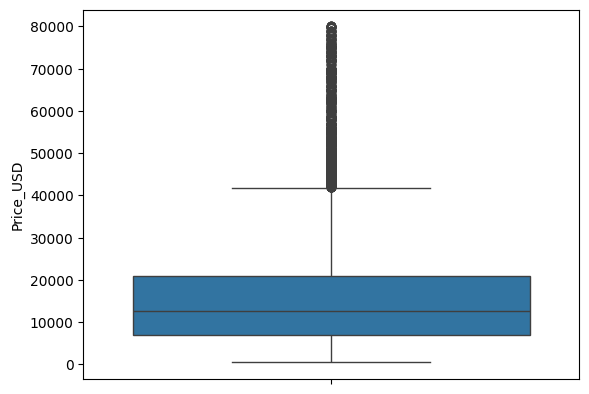

In [523]:
sns.boxplot(y_train)